### Day 1 - Load and Inspect
  * Load the CSV into Pandas
  * Print the shape, columns, and first few rows
  * Identify what each column means
  * Check for missing values

In [45]:
import pandas as pd

In [46]:
fire_df =  pd.read_csv('../data/fire_archive.csv')

In [47]:
print(f"Shape: {fire_df.shape}")

Shape: (4685568, 15)


In [48]:
fire_df.columns.tolist()

['latitude',
 'longitude',
 'brightness',
 'scan',
 'track',
 'acq_date',
 'acq_time',
 'satellite',
 'instrument',
 'confidence',
 'version',
 'bright_t31',
 'frp',
 'daynight',
 'type']

In [49]:
fire_df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-13.2704,-45.5736,311.9,1.1,1.0,2023-01-01,128,Terra,MODIS,84,61.03,291.1,12.2,N,0
1,-13.2689,-45.5637,323.4,1.1,1.0,2023-01-01,128,Terra,MODIS,100,61.03,291.7,23.8,N,0
2,-13.3373,-44.1169,303.3,1.3,1.1,2023-01-01,128,Terra,MODIS,54,61.03,292.5,7.0,N,0
3,-13.2674,-45.5538,320.0,1.1,1.0,2023-01-01,128,Terra,MODIS,100,61.03,291.2,20.0,N,0
4,41.1623,123.0031,303.4,1.3,1.1,2023-01-01,210,Terra,MODIS,56,61.03,270.7,14.8,D,2


In [50]:
fire_df.isnull().sum()

latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_t31    0
frp           0
daynight      0
type          0
dtype: int64

In [51]:
print(f"Fire types:")
print(fire_df['type'].value_counts())
# 0 - Vegetation fires
# 1 - Active volcano
# 2 - Other static land course
# 3 - Offshore detection

Fire types:
type
0    4476178
2     183693
3      19468
1       6229
Name: count, dtype: int64


In [52]:
print(f"\nConfidence range:")
print(fire_df['confidence'].value_counts()) # A percentage of how certain the satellite is that a detection is real fire.


Confidence range:
confidence
100    353538
75      91679
71      91035
69      90513
70      90485
        ...  
5         884
4         649
3         460
2         296
1         145
Name: count, Length: 101, dtype: int64


### Day 2 - Clean the data
  * Convert date columns to datetime format
  * Filter to continental US if needed
  * Handle null values in key columns like frp, brightness, and confidence
  * Drop duplicates

In [53]:
# Filter to type 0 and confidence 75 or above
fire_df = fire_df[(fire_df['type'] == 0) & (fire_df['confidence'] >= 75)]

In [54]:
fire_df.shape

(1758504, 15)

In [55]:
# Drop the columns scan, track, version, and instrument
# Scan - the horizontal satellite pixel size in kilometers.
# Track - the vertical size of the satellite pizel in kilometers (tells you how big the detection pixels are)
# Version - the version of the fire detection software (algorithm) that processed the data
# Instrument - the specific sensor on the satellite made the detection
fire_df = fire_df.drop(columns=['scan', 'track', 'version', 'instrument'])

In [56]:
# Convert acq_date to datetime format
fire_df['acq_date'] = pd.to_datetime(fire_df['acq_date'], format="%Y-%m-%d")

In [57]:
# Save as fires_clean.csv in your data/ folder
fire_df.to_csv("../data/cleaned_fire_archive.csv", index=False)

### Day 3 - Explore the Data
  * Summary statistics on key columns
  * Distribution of fire intensity (frp and brightness)
  * How many detections per month
  * Which regions have the most activity

In [58]:
cleaned_fire_df =  pd.read_csv('../data/cleaned_fire_archive.csv', parse_dates=['acq_date'])

In [59]:
# 1. Summary statistics on brightness, frp, and confidence
cleaned_fire_df[['brightness', 'frp', 'confidence']].describe()

,brightness,frp,confidence
count,1.758504e+06,1.758504e+06,1.758504e+06
mean,3.401190e+02,9.107105e+01,8.758821e+01
std,2.174496e+01,1.983366e+02,8.580432e+00
min,3.084000e+02,0.000000e+00,7.500000e+01
25%,3.273000e+02,2.430000e+01,8.000000e+01
50%,3.355000e+02,4.250000e+01,8.600000e+01
75%,3.471000e+02,8.700000e+01,9.600000e+01
max,5.105000e+02,1.399420e+04,1.000000e+02


<Axes: ylabel='Frequency'>

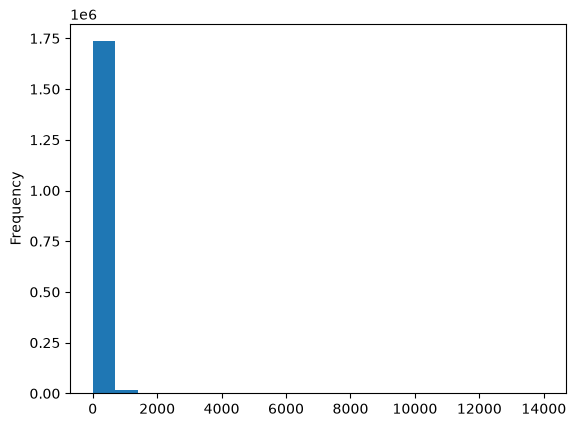

In [60]:
# 2. Distribution of fire intensity - how spread out are frp and brightness values
cleaned_fire_df['frp'].plot(kind='hist', bins=20) # frp = "Fire Radiative Power" (measures the rate of energy released by a fire in MW - Megawatts)

<Axes: ylabel='Frequency'>

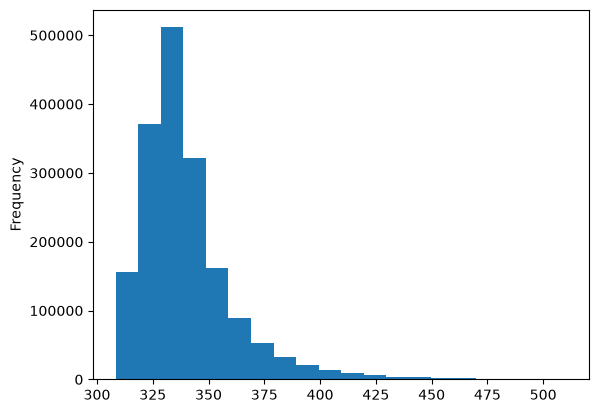

In [61]:
# positively skewed
# brightness (measures the temperature of the fire pixel in Kelvin detected by satellite sensor)
cleaned_fire_df['brightness'].plot(kind='hist', bins=20) # higher brightness = hotter fire, lower brightness = cooler fire, less intense

In [62]:
# 3. Count detections by month - is there a clear fire season peak

# Extract the month number from acq_date into a new column called month
# Group the dataframe by month and count the number of rows in each group
# Sort by month number so January through December appear in order

In [63]:
cleaned_fire_df['month'] = cleaned_fire_df['acq_date'].dt.month

In [64]:
cleaned_fire_df

,latitude,longitude,brightness,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,month
0,-13.2704,-45.5736,311.9,2023-01-01,128,Terra,84,291.1,12.2,N,0,1
1,-13.2689,-45.5637,323.4,2023-01-01,128,Terra,100,291.7,23.8,N,0,1
2,-13.2674,-45.5538,320.0,2023-01-01,128,Terra,100,291.2,20.0,N,0,1
3,43.1262,-4.0911,316.0,2023-01-01,221,Aqua,92,273.7,20.4,N,0,1
4,-20.9621,116.4452,339.8,2023-01-01,227,Terra,81,309.1,37.4,D,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1758499,31.1620,48.0582,316.4,2023-12-31,2301,Aqua,93,283.8,18.8,N,0,12
1758500,31.1464,47.6269,320.0,2023-12-31,2301,Aqua,99,282.8,23.8,N,0,12
1758501,29.0130,47.7473,312.8,2023-12-31,2302,Aqua,86,283.1,15.8,N,0,12
1758502,25.6172,50.0836,312.8,2023-12-31,2303,Aqua,86,285.0,16.1,N,0,12


In [65]:
cleaned_fire_df.groupby('month').size()

month
1     102262
2     109644
3      99557
4     102286
5     110501
6     125446
7     217703
8     248155
9     220976
10    195504
11    118050
12    108420
dtype: int64

In [66]:
cleaned_fire_df.groupby('month').size().sort_values(ascending=False)

month
8     248155
9     220976
7     217703
10    195504
6     125446
11    118050
5     110501
2     109644
12    108420
4     102286
1     102262
3      99557
dtype: int64

#### July, August, September were the 3 months in 2023 that consecutively exceeded 200,000 fire detections per month.

### Day 4 - Visualize on a Map
  * Plot fire detections on an interactive map using Folium
  * Color code by fire intensity or confidence level
  * Identify geographic clusters visually 

In [67]:
# Filter your dataset to July, August, September
cleaned_fire_df = cleaned_fire_df[(cleaned_fire_df['month'] == 7) | (cleaned_fire_df['month'] == 8) | (cleaned_fire_df['month'] == 9)]

In [68]:
cleaned_fire_df.head()

,latitude,longitude,brightness,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,month
649696,-12.9526,141.7010,344.5,2023-07-01,2,Terra,93,294.2,177.4,D,0,7
649697,-12.9449,141.7092,323.0,2023-07-01,2,Terra,79,293.3,62.6,D,0,7
649698,-12.4348,141.8997,326.8,2023-07-01,2,Terra,82,294.2,74.3,D,0,7
649699,-23.4761,148.1693,320.9,2023-07-01,5,Terra,80,292.3,18.5,D,0,7
649700,-23.4668,148.1707,325.3,2023-07-01,5,Terra,84,292.7,23.2,D,0,7


In [69]:
import folium

In [70]:
# Plot fire detections on an interactive map using Folium

In [71]:
m = folium.Map(location=[35, -105], zoom_start=5)

In [72]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [73]:
min_frp, max_frp = cleaned_fire_df['frp'].min(), cleaned_fire_df['frp'].max()

In [74]:
norm = colors.Normalize(vmin=min_frp, vmax=max_frp)

In [75]:
cmap= plt.get_cmap()

In [76]:
def get_marker_col(frp_val):
    if frp_val < 50:
        return 'yellow'
    elif frp_val >= 50 and frp_val <= 200:
        return 'orange'
    elif frp_val > 200:
        return 'red'

In [77]:
for index, row in cleaned_fire_df.iterrows():
    latitude_deg = row['latitude']
    longitude_deg = row['longitude']
    intensity = row['frp']
    pin_color = get_marker_col(intensity)
    folium.Marker(location=[latitude_deg, longitude_deg], icon=folium.Icon(color=pin_color, icon='info-sign')).add_to(m)

/var/folders/m3/j1vbwyyj7597shvb_wj67j6m0000gn/T/ipykernel_34820/1722658902.py:6: UserWarning: color argument of Icon should be one of: {'gray', 'beige', 'red', 'lightgray', 'orange', 'lightred', 'darkblue', 'lightgreen', 'pink', 'green', 'darkgreen', 'purple', 'darkpurple', 'black', 'white', 'blue', 'darkred', 'lightblue', 'cadetblue'}.
  folium.Marker(location=[latitude_deg, longitude_deg], icon=folium.Icon(color=pin_color, icon='info-sign')).add_to(m)


In [78]:
# 1. Create a Folium map object centered on the US
# 2. Loop through each row in your filtered dataframe
# 3. For each row, add a circle marker at its latitude and longitude
# 4. Set the color or size of the marker based on the frp value - higher FRP means more intense fire
# 5. Save the map as an HTML file
# 6. Open the HTML file in your browser to interact with it

In [79]:
# Center the map on the continental US


In [80]:
# Color code the detection points by fire intensity using frp


In [ ]:
# Save the map as an HTMl file and open it in your browser
m.save("fire_detection_color_coded.html")

In [ ]:
# Identify geographic clusters visually - where are the most intense fire concentrations?


### Day 5 - Temporal Analysis
  * Plot fire detections over time by month
  * Identify peak fire season in the dataset

### Day 6 - Pick Your Case Study Fire
  * Choose one well-documented 2023 wildfire to validate against later
  * Research its start date, location, and final perimeter

### Day 7 - Wrap Up
  * Commit everything to GitHub
  * Write a short summary of findings